In [4]:
from google.colab import files
uploaded = files.upload()

Saving zomato.csv.zip to zomato.csv.zip


In [5]:
import zipfile

with zipfile.ZipFile('zomato.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

import os
os.listdir()

['.config', 'zomato.csv', 'zomato.csv.zip', 'archive.zip', 'sample_data']

In [6]:
import pandas as pd

df = pd.read_csv('zomato.csv')
df.shape

(51717, 17)

In [7]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [9]:
df.isnull().sum()

,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
phone,1208
location,21
rest_type,227


In [ ]:
#Clean the data

In [10]:
#Drop columns we won't use
df = df.drop(columns=['url', 'address', 'phone', 'dish_liked', 'reviews_list', 'menu_item'])
df.shape

(51717, 11)

In [11]:
#Clean the rate column
def clean_rate(value):
    if pd.isnull(value):
        return None
    value = str(value).strip()
    if value in ['NEW', '-']:
        return None
    return float(value.split('/')[0])

df['rate'] = df['rate'].apply(clean_rate)
df['rate'].head(10)

,rate
0,4.1
1,4.1
2,3.8
3,3.7
4,3.8
5,3.8
6,3.6
7,4.6
8,4.0
9,4.2


In [12]:
#Clean the approx_cost(for two people) column
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '').astype(float)
df['approx_cost(for two people)'].head(10)

,approx_cost(for two people)
0,800.0
1,800.0
2,800.0
3,300.0
4,600.0
5,600.0
6,800.0
7,600.0
8,700.0
9,550.0


In [13]:
#Remove exact duplicate rows (common in scraped datasets like this one)
df = df.drop_duplicates()
df.shape

(51609, 11)

In [14]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 51609 entries, 0 to 51716
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         51609 non-null  object 
 1   online_order                 51609 non-null  object 
 2   book_table                   51609 non-null  object 
 3   rate                         41590 non-null  float64
 4   votes                        51609 non-null  int64  
 5   location                     51588 non-null  object 
 6   rest_type                    51382 non-null  object 
 7   cuisines                     51564 non-null  object 
 8   approx_cost(for two people)  51265 non-null  float64
 9   listed_in(type)              51609 non-null  object 
 10  listed_in(city)              51609 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 4.7+ MB


In [15]:
df = df.dropna(subset=['location', 'rest_type', 'cuisines'])
df.shape

(51358, 11)

In [ ]:
#Actual Analysis(Answering Business Questions)

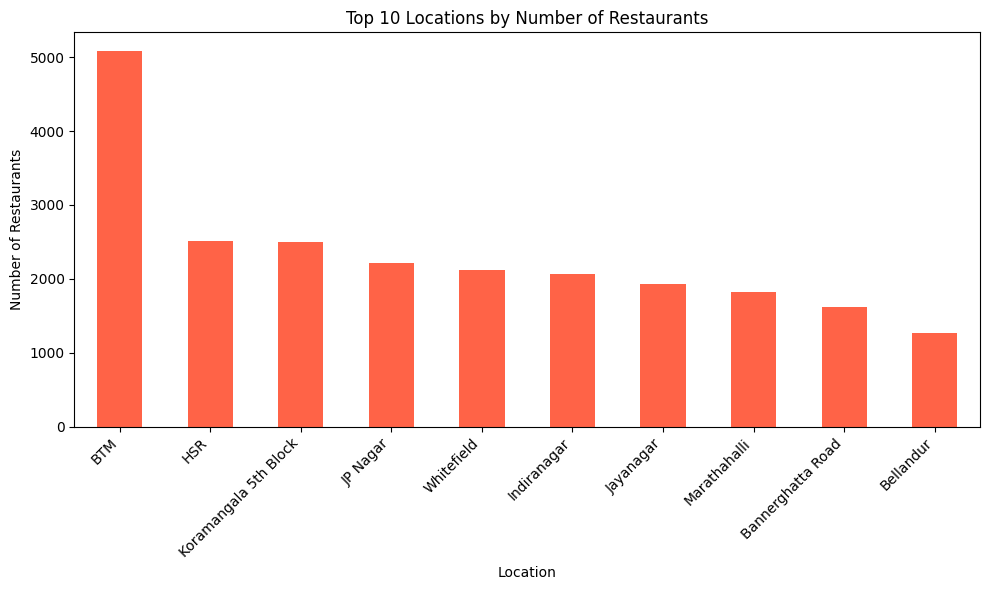

In [16]:
#Question1) Which locations have the most restaurants?
import matplotlib.pyplot as plt

top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_locations.plot(kind='bar', color='tomato')
plt.title('Top 10 Locations by Number of Restaurants')
plt.xlabel('Location')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

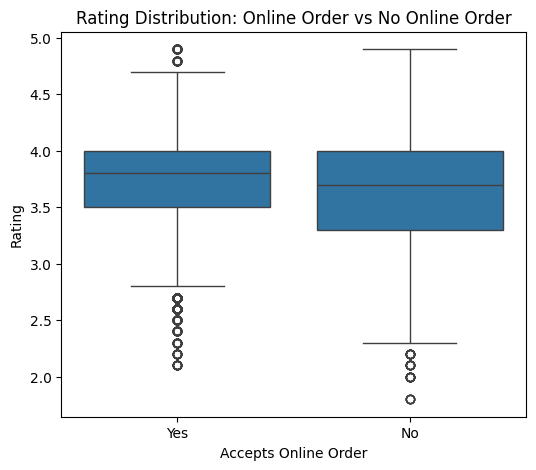

In [17]:
#Question2) Does accepting online orders correlate with a higher rating?
import seaborn as sns

plt.figure(figsize=(6,5))
sns.boxplot(x='online_order', y='rate', data=df)
plt.title('Rating Distribution: Online Order vs No Online Order')
plt.xlabel('Accepts Online Order')
plt.ylabel('Rating')
plt.show()

In [18]:
df.groupby('online_order')['rate'].mean()

,rate
online_order,
No,3.660581
Yes,3.723796


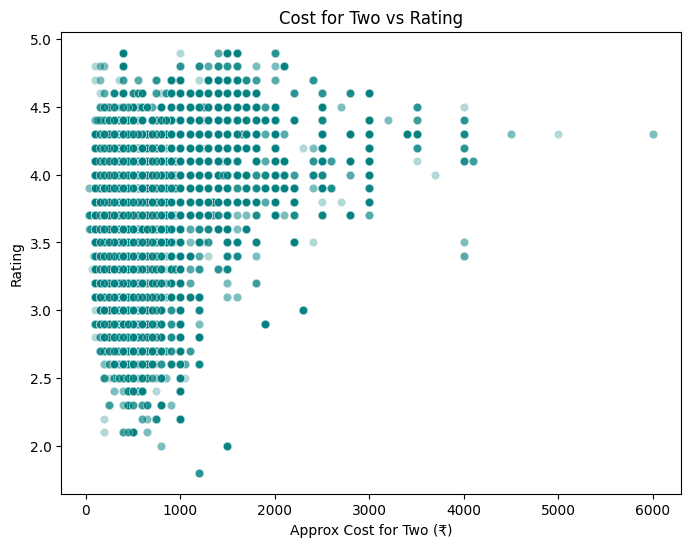

In [19]:
#Question3)  Does cost relate to rating?
plt.figure(figsize=(8,6))
sns.scatterplot(x='approx_cost(for two people)', y='rate', data=df, alpha=0.3, color='teal')
plt.title('Cost for Two vs Rating')
plt.xlabel('Approx Cost for Two (₹)')
plt.ylabel('Rating')
plt.show()

In [20]:
df['approx_cost(for two people)'].corr(df['rate'])

np.float64(0.3844808832799533)

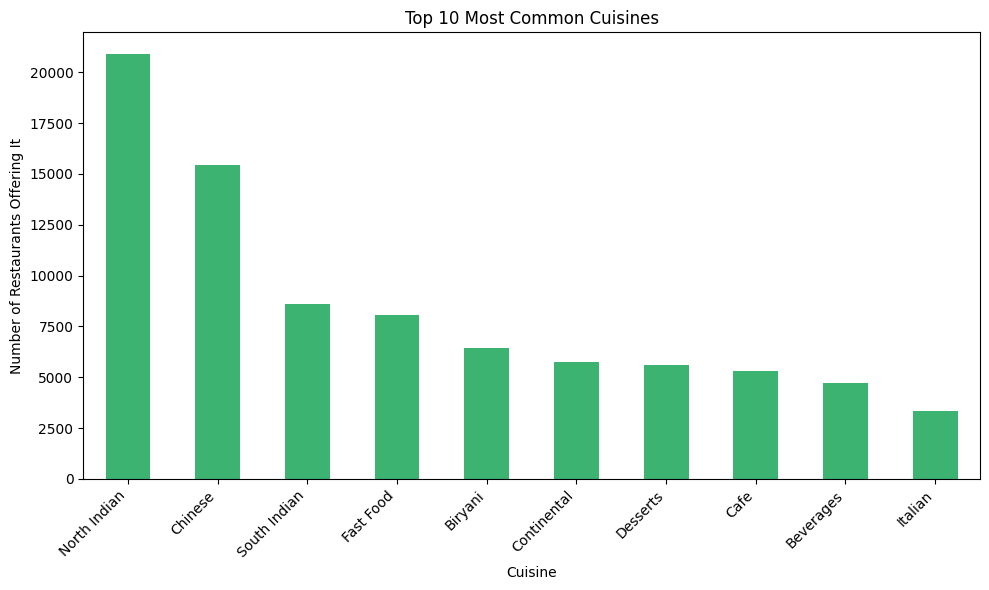

In [21]:
#Question 4) Which cuisines are most common, and how do they rate?

cuisine_df = df.copy()
cuisine_df['cuisines'] = cuisine_df['cuisines'].str.split(',')
cuisine_df = cuisine_df.explode('cuisines')
cuisine_df['cuisines'] = cuisine_df['cuisines'].str.strip()

top_cuisines = cuisine_df['cuisines'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_cuisines.plot(kind='bar', color='mediumseagreen')
plt.title('Top 10 Most Common Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Number of Restaurants Offering It')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
cuisine_stats = cuisine_df.groupby('cuisines')['rate'].agg(['mean', 'count'])
cuisine_stats = cuisine_stats[cuisine_stats['count'] >= 100]  # only cuisines with 100+ restaurants
cuisine_stats.sort_values('mean', ascending=False).head(10)

,mean,count
cuisines,,
Malaysian,4.315094,106
Modern Indian,4.307692,143
Japanese,4.257396,338
Mediterranean,4.212155,543
European,4.165103,682
Korean,4.155000,140
Asian,4.136007,1197
Steak,4.090270,555
American,4.070315,1334


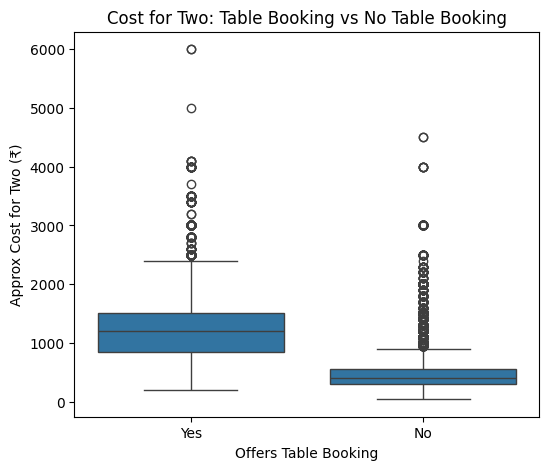

In [23]:
#Question 5) Does table booking relate to cost?
plt.figure(figsize=(6,5))
sns.boxplot(x='book_table', y='approx_cost(for two people)', data=df)
plt.title('Cost for Two: Table Booking vs No Table Booking')
plt.xlabel('Offers Table Booking')
plt.ylabel('Approx Cost for Two (₹)')
plt.show()

In [24]:
df.groupby('book_table')['approx_cost(for two people)'].mean()

,approx_cost(for two people)
book_table,
No,452.919262
Yes,1271.243766
